In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, )
from sympy.stats.rv import probability

In [34]:
columns = ['age','sex','cp','trestbps','chol','fbs',
           'restecg','thalach','exang','oldpeak',
           'slope','ca','thal','target']

df = pd.read_csv('../Data/processed.cleveland.data', names=columns, na_values='?')
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

In [35]:
# handle missing values
df['ca']   = df['ca'].fillna(df['ca'].median())
df['thal'] = df['thal'].fillna(df['thal'].median())

print(f'Data loaded: {df.shape[0]} rows, {df.shape[1]} columns')

Data loaded: 303 rows, 14 columns


In [36]:
# Data Preparation
X = df.drop('target', axis=1)
y = df['target']

In [37]:
# separate the dataset into 80% for train and 20% for test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [38]:
# Scale for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set    : {X_test.shape[0]} samples')

Training set: 242 samples
Test set    : 61 samples


## Train model

In [39]:
lr = LogisticRegression(random_state=42, max_iter=1000)
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Logistic Regression needs for scaled data, but Decision Tree and Random forest don't need it
lr.fit(X_train_scaled, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test_scaled)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)

print('Models trained successfully.')

Models trained successfully.


In [40]:
# Metrics Table
models = {
    'Logistic Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf
}

results = []
for name, y_pred in models.items():
    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1-Score' : round(f1_score(y_test, y_pred), 4)
      })

results_df = pd.DataFrame(results).set_index('Model')
print('Model Performance Comparison:')
print(results_df)

Model Performance Comparison:
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.8689     0.8125  0.9286    0.8667
Decision Tree          0.7377     0.6765  0.8214    0.7419
Random Forest          0.8852     0.8387  0.9286    0.8814


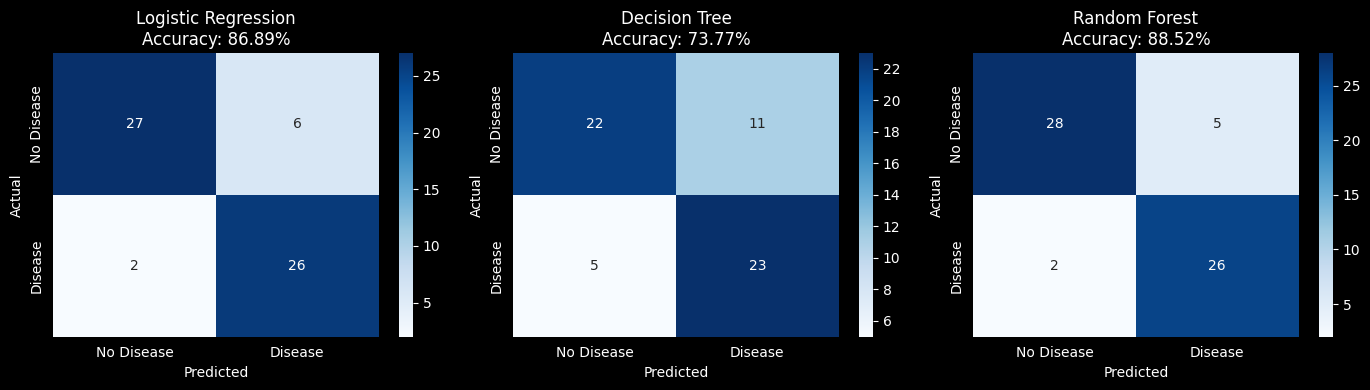

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest']
preds = [y_pred_lr, y_pred_dt, y_pred_rf]

for ax, name, y_pred in zip(axes, model_names, preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])

    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test, y_pred):.2%}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../Graphs/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

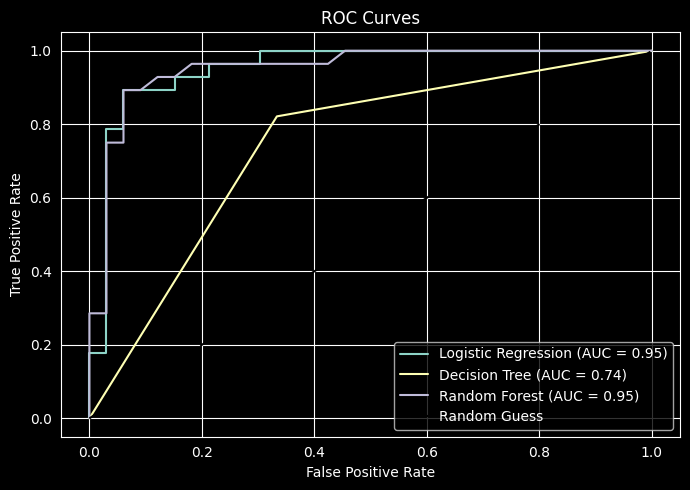

In [42]:
plt.figure(figsize=(7, 5))

for name, model, X_t in [
    ('Logistic Regression', lr, X_test_scaled),
    ('Decision Tree',       dt, X_test),
    ('Random Forest',       rf, X_test)
]:

    y_prob = model.predict_proba(X_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')


plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.tight_layout()
plt.savefig('../Graphs/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

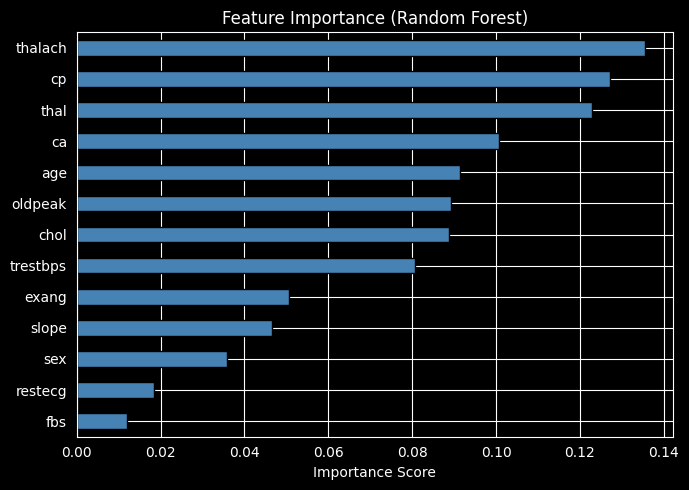

Top 5 features:
thalach    0.135404
cp         0.127163
thal       0.122940
ca         0.100811
age        0.091327
dtype: float64


In [43]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(7, 5))

importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../Graphs/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print('Top 5 features:')
print(importances.sort_values(ascending=False).head())

In [44]:
# fold cross validation for each model
models_cv = {
    'Logistic Regression': (lr, X_train_scaled),
    'Decision Tree'      : (dt, X_train),
    'Random Forest'      : (rf, X_train)
}

print('10-Fold Cross Validation Results:')
print('-' * 45)
for name, (model, X_t) in models_cv.items():
    scores = cross_val_score(model, X_t, y_train, cv=10, scoring='accuracy')
    print(f'{name}:')
    print(f'  Mean Accuracy : {scores.mean():.4f}')
    print(f'  Std Deviation : {scores.std():.4f}')
    print(f'  All Folds     : {[round(s,4) for s in scores]}')
    print()

10-Fold Cross Validation Results:
---------------------------------------------
Logistic Regression:
  Mean Accuracy : 0.8215
  Std Deviation : 0.0820
  All Folds     : [np.float64(0.88), np.float64(0.96), np.float64(0.7083), np.float64(0.8333), np.float64(0.7917), np.float64(0.9167), np.float64(0.875), np.float64(0.75), np.float64(0.7917), np.float64(0.7083)]

Decision Tree:
  Mean Accuracy : 0.7473
  Std Deviation : 0.0590
  All Folds     : [np.float64(0.8), np.float64(0.84), np.float64(0.7083), np.float64(0.75), np.float64(0.7083), np.float64(0.8333), np.float64(0.75), np.float64(0.6667), np.float64(0.75), np.float64(0.6667)]

Random Forest:
  Mean Accuracy : 0.8012
  Std Deviation : 0.0894
  All Folds     : [np.float64(0.8), np.float64(0.92), np.float64(0.7083), np.float64(0.875), np.float64(0.7917), np.float64(0.875), np.float64(0.8333), np.float64(0.625), np.float64(0.875), np.float64(0.7083)]



In [46]:
# Tune Decision Tree
dt_params = {
    'max_depth'       : [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       dt_params, cv=10, scoring='accuracy', n_jobs=-1)
dt_grid.fit(X_train, y_train)
print(f'Best DT Params  : {dt_grid.best_params_}')
print(f'Best DT CV Score: {dt_grid.best_score_:.4f}')
print()

# Tune Random Forest
rf_params = {
    'n_estimators' : [50, 100, 200],
    'max_depth'    : [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                       rf_params, cv=10, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)
print(f'Best RF Params  : {rf_grid.best_params_}')
print(f'Best RF CV Score: {rf_grid.best_score_:.4f}')

Best DT Params  : {'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best DT CV Score: 0.7803

Best RF Params  : {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}
Best RF CV Score: 0.8133


In [47]:
# Evaluate tuned models on test set
y_pred_dt_tuned = dt_grid.best_estimator_.predict(X_test)
y_pred_rf_tuned = rf_grid.best_estimator_.predict(X_test)

print('Performance After Tuning:')
print('-' * 20)
for name, y_pred in [('Decision Tree (Tuned)', y_pred_dt_tuned),
                     ('Random Forest (Tuned)', y_pred_rf_tuned)]:
    print(f'{name}:')
    print(f'  Accuracy : {accuracy_score(y_test, y_pred):.4f}')
    print(f'  Precision: {precision_score(y_test, y_pred):.4f}')
    print(f'  Recall   : {recall_score(y_test, y_pred):.4f}')
    print(f'  F1-Score : {f1_score(y_test, y_pred):.4f}')
    print()

Performance After Tuning:
--------------------
Decision Tree (Tuned):
  Accuracy : 0.8689
  Precision: 0.8571
  Recall   : 0.8571
  F1-Score : 0.8571

Random Forest (Tuned):
  Accuracy : 0.9016
  Precision: 0.8667
  Recall   : 0.9286
  F1-Score : 0.8966



In [48]:
final_results = [
    ('Logistic Regression',    y_pred_lr,       None),
    ('Decision Tree',          y_pred_dt,        None),
    ('Decision Tree (Tuned)',  y_pred_dt_tuned,  None),
    ('Random Forest',          y_pred_rf,        None),
    ('Random Forest (Tuned)',  y_pred_rf_tuned,  None),
]

print('Final Model Comparison:')
print('-' * 65)
print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print('-' * 65)

for name, y_pred, _ in final_results:
    print(f"{name:<25} {accuracy_score(y_test, y_pred):>10.4f} "
          f"{precision_score(y_test, y_pred):>10.4f} "
          f"{recall_score(y_test, y_pred):>10.4f} "
          f"{f1_score(y_test, y_pred):>10.4f}")


Final Model Comparison:
-----------------------------------------------------------------
Model                       Accuracy  Precision     Recall         F1
-----------------------------------------------------------------
Logistic Regression           0.8689     0.8125     0.9286     0.8667
Decision Tree                 0.7377     0.6765     0.8214     0.7419
Decision Tree (Tuned)         0.8689     0.8571     0.8571     0.8571
Random Forest                 0.8852     0.8387     0.9286     0.8814
Random Forest (Tuned)         0.9016     0.8667     0.9286     0.8966


In [49]:
# test model
new_patient = pd.DataFrame([[52, 1, 4, 128, 204, 1, 0, 156, 1, 1.0, 2, 0, 3.0]],columns=X.columns)

prediction = rf_grid.best_estimator_.predict(new_patient)
probability = rf_grid.best_estimator_.predict_proba(new_patient)

print(f'Prediction  : {"Heart Disease" if prediction[0] == 1 else "No Heart Disease"}')
print(f'Probability : No Disease = {probability[0][0]:.2%} | Disease = {probability[0][1]:.2%}')

Prediction  : No Heart Disease
Probability : No Disease = 54.87% | Disease = 45.13%
